In [2]:
#imports and config
from pathlib import Path
import json
import uuid
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import duckdb
from typing import List, Dict, Any


# Load & flatten


In [3]:
#raw load
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

BRONZE_ROOT = PROJECT_ROOT / "data/bronze/comtrade/monthly_history"
SILVER_ROOT = PROJECT_ROOT / "data/silver/comtrade/comtrade_fact"
SILVER_ROOT.mkdir(parents=True, exist_ok=True)

LOAD_BATCH_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ") + "_" + uuid.uuid4().hex[:8]
print(f"Using load batch ID: {LOAD_BATCH_ID}")

Using load batch ID: 20260317T233325Z_46a53589


In [4]:
def parse_filename_metadata(file_path: Path) -> dict:
    import re

    name = file_path.name
    year_match = re.search(r"year=(\d{4})", str(file_path))
    reporter_match = re.search(r"reps_(\d+)", name)
    flow_match = re.search(r"flow_([MX])", name)
    periods_match = re.search(r"periods_(\d{6})_to_(\d{6})", name)

    return {
        "source_file": name,
        "source_year_partition": int(year_match.group(1)) if year_match else None,
        "requested_reporter_code": reporter_match.group(1) if reporter_match else None,
        "requested_flow_code": flow_match.group(1) if flow_match else None,
        "requested_period_start": periods_match.group(1) if periods_match else None,
        "requested_period_end": periods_match.group(2) if periods_match else None,
    }


In [5]:

def list_comtrade_json_files(base_path: Path) -> List[Path]:
    """Recursively list all JSON files under the Comtrade bronze root."""
    files = sorted(base_path.rglob("*.json"))
    print(f"Found {len(files)} JSON files")
    return files

def load_comtrade_data_to_dataframe(file_paths: List[Path]) -> pd.DataFrame:
    """Read JSON files and combine payload records into a single DataFrame."""
    all_records = []

    for idx, json_file in enumerate(file_paths, 1):
        try:
            with open(json_file, "r", encoding="utf-8") as f:
                data = json.load(f)

            if isinstance(data, dict) and "data" in data:
                records = data["data"]
                total_count = data.get("count")

                for record in records:
                    record["source_file"] = json_file.name
                    record["source_year"] = json_file.parent.name
                    record["total_count"] = total_count

                all_records.extend(records)

                if idx % 50 == 0:
                    print(f"Processed {idx}/{len(file_paths)} files, total records: {len(all_records)}")
            else:
                print(f"Unexpected structure in {json_file}")

        except Exception as e:
            print(f"Error reading {json_file}: {e}")
            continue

    print(f"\nCreating DataFrame with {len(all_records)} total records...")
    df = pd.DataFrame(all_records)
    print(f"DataFrame shape: {df.shape}")
    return df

# Usage
json_file_paths = list_comtrade_json_files(BRONZE_ROOT)
print("First 3 files:")
for p in json_file_paths[:3]:
    print(f" - {p}")

df = load_comtrade_data_to_dataframe(json_file_paths)
df.head()

Found 288 JSON files
First 3 files:
 - /Users/chromazone/Documents/Python/Data Enginering Zoomcamp/Capstone_monthly/data/bronze/comtrade/monthly_history/year=2020/hist_batch_reps_100_cmd_1001-1005-1006-1201-2709-2710_periods_202001_to_202004_flow_M_20260312_121526.json
 - /Users/chromazone/Documents/Python/Data Enginering Zoomcamp/Capstone_monthly/data/bronze/comtrade/monthly_history/year=2020/hist_batch_reps_100_cmd_1001-1005-1006-1201-2709-2710_periods_202001_to_202004_flow_X_20260312_121540.json
 - /Users/chromazone/Documents/Python/Data Enginering Zoomcamp/Capstone_monthly/data/bronze/comtrade/monthly_history/year=2020/hist_batch_reps_100_cmd_1001-1005-1006-1201-2709-2710_periods_202005_to_202008_flow_M_20260312_121555.json
Processed 50/288 files, total records: 162414
Processed 100/288 files, total records: 339305
Processed 150/288 files, total records: 537573
Processed 200/288 files, total records: 756372
Processed 250/288 files, total records: 968968

Creating DataFrame with 108

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate,source_file,source_year,total_count
0,C,M,20200101,2020,1,202001,100,BGR,Bulgaria,M,...,False,1.058049e+06,0.0,1.058049e+06,0,False,True,hist_batch_reps_100_cmd_1001-1005-1006-1201-27...,year=2020,1398
1,C,M,20200101,2020,1,202001,100,BGR,Bulgaria,M,...,False,1.028874e+07,0.0,1.028874e+07,0,False,True,hist_batch_reps_100_cmd_1001-1005-1006-1201-27...,year=2020,1398
2,C,M,20200101,2020,1,202001,100,BGR,Bulgaria,M,...,False,1.634398e+05,0.0,1.634398e+05,0,False,True,hist_batch_reps_100_cmd_1001-1005-1006-1201-27...,year=2020,1398
3,C,M,20200101,2020,1,202001,100,BGR,Bulgaria,M,...,False,5.793973e+05,0.0,5.793973e+05,0,False,True,hist_batch_reps_100_cmd_1001-1005-1006-1201-27...,year=2020,1398
4,C,M,20200101,2020,1,202001,100,BGR,Bulgaria,M,...,False,3.848297e+04,0.0,3.848297e+04,0,False,True,hist_batch_reps_100_cmd_1001-1005-1006-1201-27...,year=2020,1398


In [6]:
json_files = sorted(BRONZE_ROOT.rglob("*.json"))
json_files = [f for f in json_files if "__MACOSX" not in str(f) and not f.name.startswith("._")]


In [7]:
frames = []

for file_path in json_files:
    with open(file_path, "r", encoding="utf-8") as f:
        obj = json.load(f)

    df = pd.DataFrame(obj.get("data", []))
    if df.empty:
        continue

    meta = obj.get("_metadata", {})
    file_meta = parse_filename_metadata(file_path)

    for key, value in file_meta.items():
        df[key] = value

    df["bronze_extracted_at"] = meta.get("extracted_at_utc")
    df["load_batch_id"] = LOAD_BATCH_ID

    frames.append(df)

raw_df = pd.concat(frames, ignore_index=True)
raw_df.shape


(1085896, 55)

In [8]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1085896 entries, 0 to 1085895
Data columns (total 55 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   typeCode                  1085896 non-null  str    
 1   freqCode                  1085896 non-null  str    
 2   refPeriodId               1085896 non-null  int64  
 3   refYear                   1085896 non-null  int64  
 4   refMonth                  1085896 non-null  int64  
 5   period                    1085896 non-null  str    
 6   reporterCode              1085896 non-null  int64  
 7   reporterISO               1085896 non-null  str    
 8   reporterDesc              1085896 non-null  str    
 9   flowCode                  1085896 non-null  str    
 10  flowDesc                  1085896 non-null  str    
 11  partnerCode               1085896 non-null  int64  
 12  partnerISO                1085896 non-null  str    
 13  partnerDesc               1085896 non-

In [9]:
raw_df.head()

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,isReported,isAggregate,source_file,source_year_partition,requested_reporter_code,requested_flow_code,requested_period_start,requested_period_end,bronze_extracted_at,load_batch_id
0,C,M,20200101,2020,1,202001,100,BGR,Bulgaria,M,...,False,True,hist_batch_reps_100_cmd_1001-1005-1006-1201-27...,2020,100,M,202001,202004,2026-03-12T11:15:26.112854+00:00,20260317T233325Z_46a53589
1,C,M,20200101,2020,1,202001,100,BGR,Bulgaria,M,...,False,True,hist_batch_reps_100_cmd_1001-1005-1006-1201-27...,2020,100,M,202001,202004,2026-03-12T11:15:26.112854+00:00,20260317T233325Z_46a53589
2,C,M,20200101,2020,1,202001,100,BGR,Bulgaria,M,...,False,True,hist_batch_reps_100_cmd_1001-1005-1006-1201-27...,2020,100,M,202001,202004,2026-03-12T11:15:26.112854+00:00,20260317T233325Z_46a53589
3,C,M,20200101,2020,1,202001,100,BGR,Bulgaria,M,...,False,True,hist_batch_reps_100_cmd_1001-1005-1006-1201-27...,2020,100,M,202001,202004,2026-03-12T11:15:26.112854+00:00,20260317T233325Z_46a53589
4,C,M,20200101,2020,1,202001,100,BGR,Bulgaria,M,...,False,True,hist_batch_reps_100_cmd_1001-1005-1006-1201-27...,2020,100,M,202001,202004,2026-03-12T11:15:26.112854+00:00,20260317T233325Z_46a53589


In [10]:
#schema audit
int_cols = ["refYear", "refMonth", "period", "aggrLevel", "reporterCode", "partnerCode"]
float_cols = ["qty", "altQty", "netWgt", "grossWgt", "cifvalue", "fobvalue", "primaryValue"]
bool_cols = [
    "isOriginalClassification", "isLeaf", "isQtyEstimated", "isAltQtyEstimated",
    "isNetWgtEstimated", "isGrossWgtEstimated", "isReported", "isAggregate"
]

for col in int_cols:
    raw_df[col] = pd.to_numeric(raw_df[col], errors="coerce").astype("Int64")

for col in float_cols:
    raw_df[col] = pd.to_numeric(raw_df[col], errors="coerce")

for col in bool_cols:
    raw_df[col] = raw_df[col].astype("boolean")

raw_df["bronze_extracted_at"] = pd.to_datetime(raw_df["bronze_extracted_at"], errors="coerce", utc=True)
raw_df["load_batch_id"] = raw_df["load_batch_id"].astype(str)

In [11]:
# derive date fields

raw_df["period_str"] = raw_df["period"].astype(str)
raw_df["ref_date"] = pd.to_datetime(raw_df["period_str"] + "01", format="%Y%m%d", errors="coerce")
raw_df["year_month"] = raw_df["ref_date"].dt.strftime("%Y-%m")
raw_df["quarter"] = raw_df["ref_date"].dt.to_period("Q").astype(str)
raw_df["ref_year"] = raw_df["ref_date"].dt.year.astype("Int64")


In [12]:
# Standardise reporter and partner fields

raw_df["reporter_iso3"] = raw_df["reporterISO"].astype(str).str.strip().str.upper()
raw_df["partner_iso3"] = raw_df["partnerISO"].astype(str).str.strip().str.upper()

raw_df["reporter_name_clean"] = raw_df["reporterDesc"].astype(str).str.strip()
raw_df["partner_name_clean"] = raw_df["partnerDesc"].astype(str).str.strip()


In [13]:
#Partner flags

SPECIAL_PARTNER_CODES = {"W00"}

raw_df["is_world_partner"] = raw_df["partner_iso3"].eq("W00")
raw_df["is_special_partner_bucket"] = raw_df["partner_iso3"].isin(SPECIAL_PARTNER_CODES)
raw_df["is_country_like_partner"] = ~raw_df["is_special_partner_bucket"]
raw_df["is_bilateral_usable"] = ~raw_df["is_world_partner"]


In [17]:
# Normalise flow
flow_map = {"M": "import", "X": "export"}
raw_df["trade_flow"] = raw_df["flowCode"].map(flow_map)
raw_df["flow_sign"] = raw_df["flowCode"].map({"M": 1, "X": -1})


In [18]:
# Handle trade value correctly

raw_df["trade_value_usd"] = raw_df["primaryValue"]
raw_df["value_basis"] = "primary"

import_mask = raw_df["trade_flow"].eq("import") & raw_df["trade_value_usd"].isna()
export_mask = raw_df["trade_flow"].eq("export") & raw_df["trade_value_usd"].isna()

raw_df.loc[import_mask, "trade_value_usd"] = raw_df.loc[import_mask, "cifvalue"]
raw_df.loc[import_mask, "value_basis"] = "cif_fallback"

raw_df.loc[export_mask, "trade_value_usd"] = raw_df.loc[export_mask, "fobvalue"]
raw_df.loc[export_mask, "value_basis"] = "fob_fallback"


In [19]:
#. Quantity and weight flags

raw_df["has_qty"] = raw_df["qty"].fillna(0) > 0
raw_df["has_alt_qty"] = raw_df["altQty"].fillna(0) > 0
raw_df["has_net_wgt"] = raw_df["netWgt"].fillna(0) > 0
raw_df["has_gross_wgt"] = raw_df["grossWgt"].fillna(0) > 0

raw_df["is_weight_usable"] = raw_df["has_net_wgt"] | raw_df["has_gross_wgt"]
raw_df["is_qty_usable"] = raw_df["has_qty"] & raw_df["qtyUnitAbbr"].notna() & raw_df["qtyUnitAbbr"].ne("N/A")


In [20]:
# Derived metrics

raw_df["value_per_net_kg_usd"] = np.where(
    raw_df["netWgt"] > 0,
    raw_df["trade_value_usd"] / raw_df["netWgt"],
    np.nan
)

raw_df["value_per_gross_kg_usd"] = np.where(
    raw_df["grossWgt"] > 0,
    raw_df["trade_value_usd"] / raw_df["grossWgt"],
    np.nan
)

raw_df["value_per_qty_unit"] = np.where(
    (raw_df["qty"] > 0) & raw_df["is_qty_usable"],
    raw_df["trade_value_usd"] / raw_df["qty"],
    np.nan
)


In [21]:
# Classification and comparability flags

raw_df["classification_version"] = raw_df["classificationCode"].astype(str).str.strip().str.upper()

raw_df["is_cross_revision_series"] = raw_df["cmdCode"].astype(str).isin(["1001", "1005", "1006", "1201", "2709", "2710"])
raw_df["classification_is_comparable"] = True


In [23]:
# Guard against double counting

raw_df["analysis_grain"] = (
    raw_df["period"].astype(str) + "|" +
    raw_df["reporter_iso3"] + "|" +
    raw_df["partner_iso3"] + "|" +
    raw_df["flowCode"].astype(str) + "|" +
    raw_df["cmdCode"].astype(str) + "|" +
    raw_df["classification_version"] + "|" +
    raw_df["customsCode"].astype(str)  + "|" +
    raw_df["motCode"].astype(str)  + "|" +
    raw_df["partner2Code"].astype(str)  + "|" 
)
raw_df["is_commodity_rollup_safe"] = ~raw_df["isAggregate"].fillna(False)


In [25]:
# Select final silver columns

silver_cols = [
    "load_batch_id",
    "source_file",
    "source_year_partition",
    "bronze_extracted_at",

    "ref_date",
    "year_month",
    "quarter",
    "ref_year",
    "refMonth",
    "period",

    "reporterCode",
    "reporter_iso3",
    "reporter_name_clean",
    "partnerCode",
    "partner_iso3",
    "partner_name_clean",

    "is_world_partner",
    "is_special_partner_bucket",
    "is_country_like_partner",
    "is_bilateral_usable",

    "flowCode",
    "trade_flow",
    "flow_sign",

    "classificationCode",
    "classification_version",
    "classificationSearchCode",
    "isOriginalClassification",

    "cmdCode",
    "cmdDesc",
    "aggrLevel",
    "isLeaf",
    "isAggregate",
    "is_commodity_rollup_safe",
    "analysis_grain",

    "qtyUnitCode",
    "qtyUnitAbbr",
    "qty",
    "altQtyUnitCode",
    "altQtyUnitAbbr",
    "altQty",
    "netWgt",
    "grossWgt",

    "has_qty",
    "has_alt_qty",
    "has_net_wgt",
    "has_gross_wgt",
    "is_weight_usable",
    "is_qty_usable",

    "isQtyEstimated",
    "isAltQtyEstimated",
    "isNetWgtEstimated",
    "isGrossWgtEstimated",
    "legacyEstimationFlag",
    "isReported",

    "cifvalue",
    "fobvalue",
    "primaryValue",
    "trade_value_usd",
    "value_basis",

    "value_per_net_kg_usd",
    "value_per_gross_kg_usd",
    "value_per_qty_unit",
    "customsCode",
    "motCode",
    "partner2Code"
]


In [26]:
silver_df = raw_df[silver_cols].copy()
silver_df.head()


,load_batch_id,source_file,source_year_partition,bronze_extracted_at,ref_date,year_month,quarter,ref_year,refMonth,period,...,fobvalue,primaryValue,trade_value_usd,value_basis,value_per_net_kg_usd,value_per_gross_kg_usd,value_per_qty_unit,customsCode,motCode,partner2Code
0,20260317T233325Z_46a53589,hist_batch_reps_100_cmd_1001-1005-1006-1201-27...,2020,2026-03-12 11:15:26.112854+00:00,2020-01-01,2020-01,2020Q1,2020,1,202001,...,0.0,1.058049e+06,1.058049e+06,primary,3.055684,NaN,3.055684,C20,3200,0
1,20260317T233325Z_46a53589,hist_batch_reps_100_cmd_1001-1005-1006-1201-27...,2020,2026-03-12 11:15:26.112854+00:00,2020-01-01,2020-01,2020Q1,2020,1,202001,...,0.0,1.028874e+07,1.028874e+07,primary,0.598095,NaN,0.598095,C20,3200,0
2,20260317T233325Z_46a53589,hist_batch_reps_100_cmd_1001-1005-1006-1201-27...,2020,2026-03-12 11:15:26.112854+00:00,2020-01-01,2020-01,2020Q1,2020,1,202001,...,0.0,1.634398e+05,1.634398e+05,primary,1.069325,NaN,1.069325,C20,3200,0
3,20260317T233325Z_46a53589,hist_batch_reps_100_cmd_1001-1005-1006-1201-27...,2020,2026-03-12 11:15:26.112854+00:00,2020-01-01,2020-01,2020Q1,2020,1,202001,...,0.0,5.793973e+05,5.793973e+05,primary,2.277433,NaN,2.277433,C20,3200,0
4,20260317T233325Z_46a53589,hist_batch_reps_100_cmd_1001-1005-1006-1201-27...,2020,2026-03-12 11:15:26.112854+00:00,2020-01-01,2020-01,2020Q1,2020,1,202001,...,0.0,3.848297e+04,3.848297e+04,primary,1.794747,NaN,1.794747,C20,3200,0


In [27]:
# Duplicate check at intended silver grain  

silver_grain = ["period", "reporter_iso3", "partner_iso3", "flowCode", "cmdCode", "classification_version","customsCode", "motCode", "partner2Code"]

dup_count = silver_df.duplicated(subset=silver_grain).sum()
dup_count


np.int64(0)

In [28]:
# Write partitioned parquet

for (ref_year, reporter_iso3), part_df in silver_df.groupby(["ref_year", "reporter_iso3"], dropna=False):
    out_dir = SILVER_ROOT / f"ref_year={ref_year}" / f"reporter_iso3={reporter_iso3}"
    out_dir.mkdir(parents=True, exist_ok=True)

    part_df = part_df.sort_values(["period", "partner_iso3", "cmdCode", "flowCode"])
    out_file = out_dir / f"part_{LOAD_BATCH_ID}.parquet"
    part_df.to_parquet(out_file, index=False)

In [29]:
silver_df.shape

(1085896, 65)

In [30]:
# Verify with DuckDB

con = duckdb.connect()
con.sql(f"""
    SELECT ref_year, reporter_iso3, flowCode, COUNT(*) AS rows
    FROM read_parquet('{SILVER_ROOT}/**/*.parquet')
    GROUP BY 1,2,3
    ORDER BY 1,2,3
""").df()


,ref_year,reporter_iso3,flowCode,rows
0,2020,BGR,M,4254
1,2020,BGR,X,5559
2,2020,CHN,M,1472
3,2020,CHN,X,2155
4,2020,ESP,M,31857
...,...,...,...,...
87,2025,NLD,X,3156
88,2025,ROU,M,14532
89,2025,ROU,X,12854
90,2025,USA,M,1531


SILVER HELPER TABLES

In [31]:
import matplotlib.pyplot as plt

1. silver_comtrade_partner_month

In [32]:
partner_month = (
    silver_df[silver_df["is_bilateral_usable"]]
    .groupby(["ref_date", "period", "year_month", "ref_year", "reporter_iso3", "partner_iso3", "trade_flow"], as_index=False)
    .agg(
        trade_value_usd=("trade_value_usd", "sum"),
        netWgt=("netWgt", "sum"),
        grossWgt=("grossWgt", "sum"),
        row_count=("cmdCode", "count"),
    )
)


In [33]:
partner_month.to_parquet(SILVER_ROOT / "partner_month.parquet", index=False)

In [34]:
partner_dupes = partner_month.duplicated(subset=["period", "reporter_iso3", "partner_iso3", "trade_flow"], keep=False).sum()

print("partner_month duplicates:", partner_dupes)

partner_month duplicates: 0


In [35]:
partner_month.isna().mean().sort_values(ascending=False)

ref_date           0.0
period             0.0
year_month         0.0
ref_year           0.0
reporter_iso3      0.0
partner_iso3       0.0
trade_flow         0.0
trade_value_usd    0.0
netWgt             0.0
grossWgt           0.0
row_count          0.0
dtype: float64

In [36]:
partner_month.groupby("reporter_iso3")["period"].nunique().sort_values()


reporter_iso3
CHN    60
FRA    60
BGR    69
ROU    69
ESP    70
NLD    70
USA    70
EUR    72
Name: period, dtype: int64

In [37]:
partner_month[partner_month["trade_value_usd"] <= 0].head(20)


,ref_date,period,year_month,ref_year,reporter_iso3,partner_iso3,trade_flow,trade_value_usd,netWgt,grossWgt,row_count


In [38]:
# Highest Partner trade overall

partner_month.sort_values("trade_value_usd", ascending=False)[
    ["ref_date", "reporter_iso3", "partner_iso3", "trade_flow", "trade_value_usd"]
].head(25)


,ref_date,reporter_iso3,partner_iso3,trade_flow,trade_value_usd
41464,2022-03-01,EUR,RUS,import,2.140354e+10
39836,2022-02-01,EUR,RUS,import,2.071844e+10
46343,2022-06-01,EUR,RUS,import,1.922933e+10
38256,2022-01-01,EUR,RUS,import,1.886017e+10
43103,2022-04-01,EUR,RUS,import,1.799025e+10
47978,2022-07-01,EUR,RUS,import,1.767482e+10
35036,2021-11-01,EUR,RUS,import,1.654727e+10
33423,2021-10-01,EUR,RUS,import,1.639752e+10
676,2020-01-01,EUR,RUS,import,1.613018e+10
36636,2021-12-01,EUR,RUS,import,1.601217e+10


In [39]:
# Top Partners

top_partners = (
    partner_month.groupby(["reporter_iso3", "partner_iso3"], as_index=False)
    ["trade_value_usd"].sum()
    .sort_values(["reporter_iso3", "trade_value_usd"], ascending=[True, False])
)

top_partners.groupby("reporter_iso3").head(10)


,reporter_iso3,partner_iso3,trade_value_usd
116,BGR,RUS,3.950286e+10
115,BGR,ROU,1.550119e+10
43,BGR,EGY,1.204595e+10
55,BGR,GRC,1.040121e+10
72,BGR,KAZ,9.124274e+09
...,...,...,...
1338,USA,BRA,8.593024e+10
1471,USA,SAU,7.625175e+10
1379,USA,GBR,7.292412e+10
1352,USA,COL,7.130145e+10


In [40]:
top_partners_by_flow = (
    partner_month.groupby(["reporter_iso3", "partner_iso3", "trade_flow"], as_index=False)
    ["trade_value_usd"].sum()
    .sort_values(["reporter_iso3", "trade_flow", "trade_value_usd"], ascending=[True, True, False])
)

top_partners_by_flow.groupby(["reporter_iso3", "trade_flow"]).head(10)


,reporter_iso3,partner_iso3,trade_flow,trade_value_usd
61,BGR,DZA,export,7.826068e+09
66,BGR,EGY,export,7.741922e+09
185,BGR,ROU,export,6.361397e+09
85,BGR,GIB,export,6.208388e+09
225,BGR,UKR,export,5.891294e+09
...,...,...,...,...
2356,USA,BRA,import,3.793545e+10
2592,USA,RUS,import,3.288216e+10
2495,USA,KOR,import,2.542710e+10
2409,USA,ECU,import,2.408537e+10


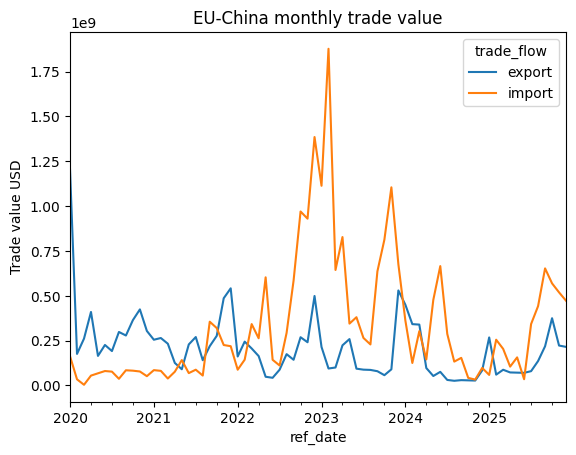

In [42]:
eur_chn = partner_month[
    (partner_month["reporter_iso3"] == "EUR") &
    (partner_month["partner_iso3"] == "CHN")
].sort_values("ref_date")

eur_chn.pivot(index="ref_date", columns="trade_flow", values="trade_value_usd").plot(
    title="EU-China monthly trade value"
)
plt.ylabel("Trade value USD")
plt.show()


2. silver_comtrade_cmd_month

In [43]:
cmd_month = (
    silver_df
    .groupby(["ref_date", "period", "year_month", "ref_year", "reporter_iso3", "cmdCode", "cmdDesc", "trade_flow"], as_index=False)
    .agg(
        trade_value_usd=("trade_value_usd", "sum"),
        netWgt=("netWgt", "sum"),
        grossWgt=("grossWgt", "sum"),
        row_count=("partner_iso3", "count"),
    )
)


In [44]:
cmd_month.to_parquet(SILVER_ROOT / "cmd_month.parquet", index=False)

In [45]:
cmd_dupes = cmd_month.duplicated(
    subset=["period", "reporter_iso3", "cmdCode", "trade_flow"]
).sum()

print("cmd_month duplicates:", cmd_dupes)

cmd_month duplicates: 0


In [46]:
# Highest commodity trade values

cmd_month.sort_values("trade_value_usd", ascending=False)[
    ["ref_date", "reporter_iso3", "cmdCode", "cmdDesc", "trade_flow", "trade_value_usd"]
].head(25)


,ref_date,reporter_iso3,cmdCode,cmdDesc,trade_flow,trade_value_usd
2753,2022-06-01,EUR,2709,Petroleum oils and oils obtained from bitumino...,import,1.481897e+11
2848,2022-07-01,EUR,2709,Petroleum oils and oils obtained from bitumino...,import,1.344885e+11
2943,2022-08-01,EUR,2709,Petroleum oils and oils obtained from bitumino...,import,1.269777e+11
2659,2022-05-01,EUR,2709,Petroleum oils and oils obtained from bitumino...,import,1.228459e+11
2472,2022-03-01,EUR,2709,Petroleum oils and oils obtained from bitumino...,import,1.182988e+11
2566,2022-04-01,EUR,2709,Petroleum oils and oils obtained from bitumino...,import,1.177343e+11
4263,2023-10-01,EUR,2709,Petroleum oils and oils obtained from bitumino...,import,1.119341e+11
3226,2022-11-01,EUR,2709,Petroleum oils and oils obtained from bitumino...,import,1.091689e+11
3415,2023-01-01,EUR,2709,Petroleum oils and oils obtained from bitumino...,import,1.064549e+11
3038,2022-09-01,EUR,2709,Petroleum oils and oils obtained from bitumino...,import,1.064538e+11


In [47]:
top_cmds = (
    cmd_month.groupby(["reporter_iso3", "cmdCode", "cmdDesc", "trade_flow"], as_index=False)
    ["trade_value_usd"].sum()
    .sort_values(["reporter_iso3", "trade_flow", "trade_value_usd"], ascending=[True, True, False])
)

top_cmds.groupby(["reporter_iso3", "trade_flow"]).head(10)


,reporter_iso3,cmdCode,cmdDesc,trade_flow,trade_value_usd
10,BGR,2710,Petroleum oils and oils from bituminous minera...,export,1.036855e+11
0,BGR,1001,Wheat and meslin,export,5.966224e+10
2,BGR,1005,Maize (corn),export,1.597031e+10
4,BGR,1006,Rice,export,3.067383e+09
6,BGR,1201,"Soya beans, whether or not broken",export,1.170967e+07
...,...,...,...,...,...
95,USA,2710,Petroleum oils and oils from bituminous minera...,import,7.043793e+11
89,USA,1006,Rice,import,1.627730e+10
85,USA,1001,Wheat and meslin,import,7.700049e+09
91,USA,1201,"Soya beans, whether or not broken",import,5.088145e+09


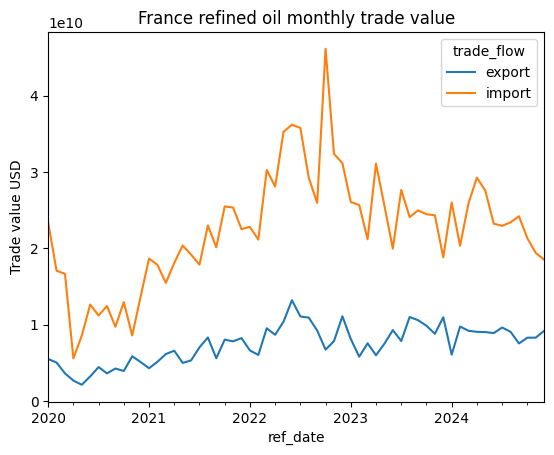

In [48]:
fra_2710 = cmd_month[
    (cmd_month["reporter_iso3"] == "FRA") &
    (cmd_month["cmdCode"].astype(str) == "2710")
].sort_values("ref_date")

fra_2710.pivot(index="ref_date", columns="trade_flow", values="trade_value_usd").plot(
    title="France refined oil monthly trade value"
)
plt.ylabel("Trade value USD")
plt.show()


3. silver_comtrade_reporter_month

In [49]:
reporter_month = (
    silver_df
    .groupby(["ref_date", "period", "year_month", "ref_year", "reporter_iso3", "trade_flow"], as_index=False)
    .agg(
        trade_value_usd=("trade_value_usd", "sum"),
        netWgt=("netWgt", "sum"),
        grossWgt=("grossWgt", "sum"),
        row_count=("cmdCode", "count"),
    )
)


In [50]:
reporter_month.to_parquet(SILVER_ROOT / "reporter_month.parquet", index=False)

In [51]:
reporter_dupes = reporter_month.duplicated(
    subset=["period", "reporter_iso3", "trade_flow"]
).sum()

print("reporter_month duplicates:", reporter_dupes)

reporter_month duplicates: 0


In [52]:
#Highest reporter months

reporter_month.sort_values("trade_value_usd", ascending=False)[
    ["ref_date", "reporter_iso3", "trade_flow", "trade_value_usd"]
].head(25)


,ref_date,reporter_iso3,trade_flow,trade_value_usd
471,2022-06-01,EUR,import,1.927619e+11
487,2022-07-01,EUR,import,1.793738e+11
503,2022-08-01,EUR,import,1.689490e+11
455,2022-05-01,EUR,import,1.675120e+11
439,2022-04-01,EUR,import,1.609823e+11
423,2022-03-01,EUR,import,1.585232e+11
535,2022-10-01,EUR,import,1.562639e+11
551,2022-11-01,EUR,import,1.545344e+11
567,2022-12-01,EUR,import,1.516250e+11
583,2023-01-01,EUR,import,1.504388e+11


In [53]:
reporter_month.sort_values("ref_date").head()


,ref_date,period,year_month,ref_year,reporter_iso3,trade_flow,trade_value_usd,netWgt,grossWgt,row_count
0,2020-01-01,202001,2020-01,2020,BGR,export,2.345214e+09,6.200787e+09,0.0,511
15,2020-01-01,202001,2020-01,2020,USA,import,3.116583e+10,8.369697e+10,0.0,147
14,2020-01-01,202001,2020-01,2020,USA,export,3.351450e+10,3.913598e+10,0.0,390
13,2020-01-01,202001,2020-01,2020,ROU,import,2.181993e+09,4.510375e+09,0.0,330
12,2020-01-01,202001,2020-01,2020,ROU,export,1.806566e+09,5.654974e+09,0.0,405


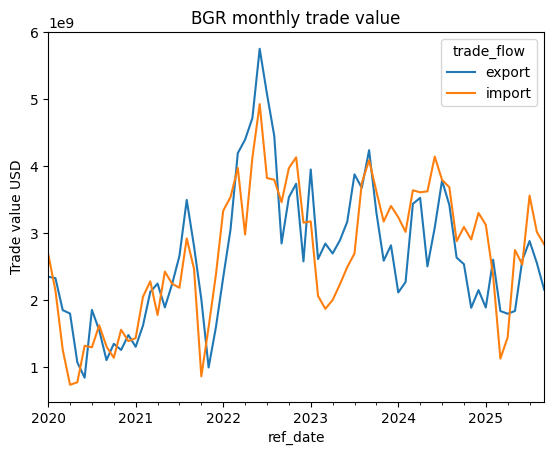

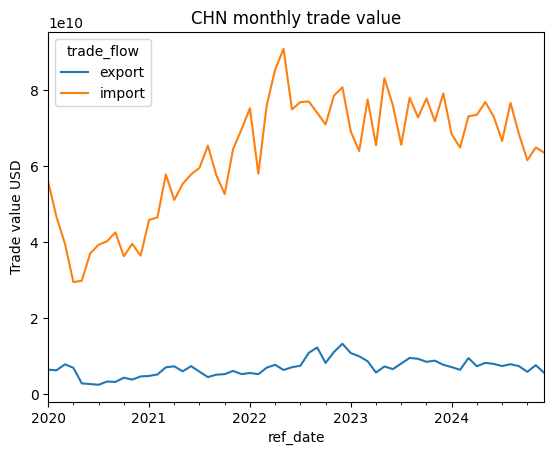

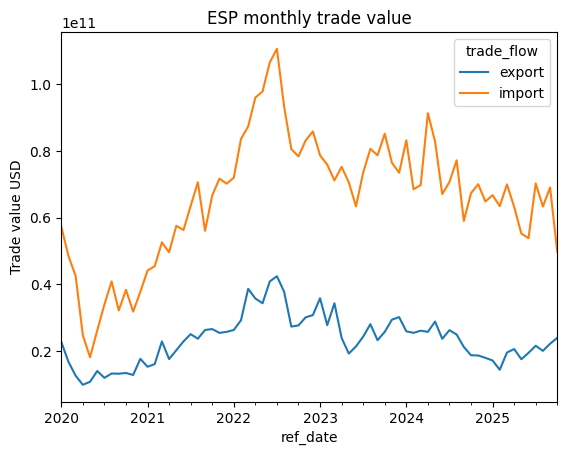

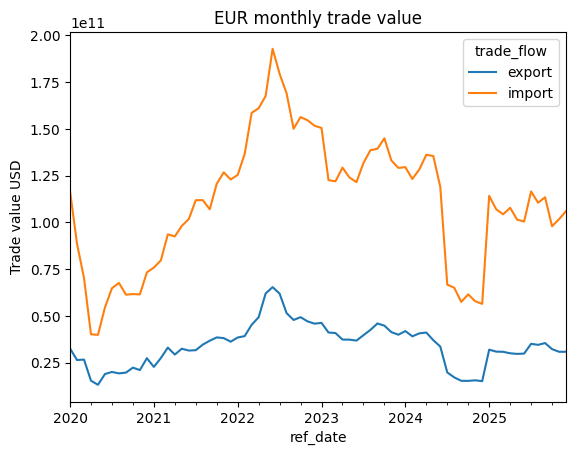

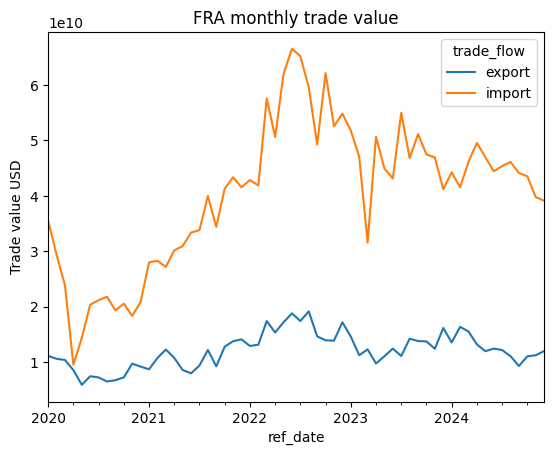

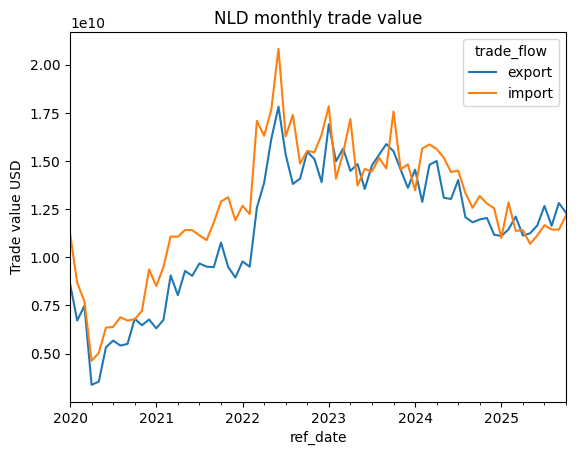

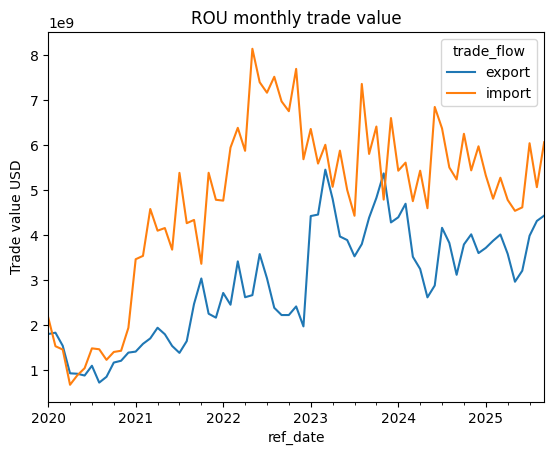

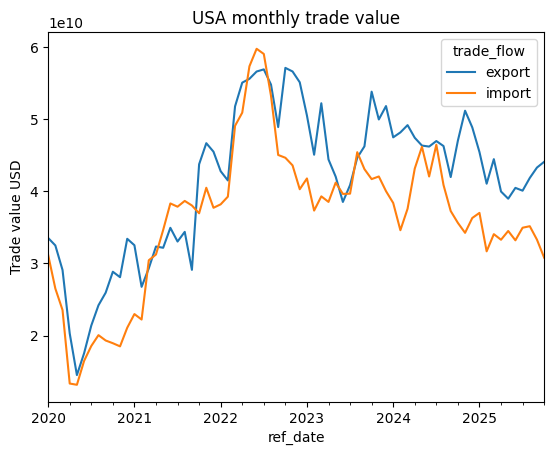

In [54]:
import matplotlib.pyplot as plt

for reporter in sorted(reporter_month["reporter_iso3"].dropna().unique()):
    subset = reporter_month[reporter_month["reporter_iso3"] == reporter].copy()
    subset = subset.sort_values("ref_date")

    pivot = subset.pivot(index="ref_date", columns="trade_flow", values="trade_value_usd")
    pivot.plot(title=f"{reporter} monthly trade value")
    plt.ylabel("Trade value USD")
    plt.show()


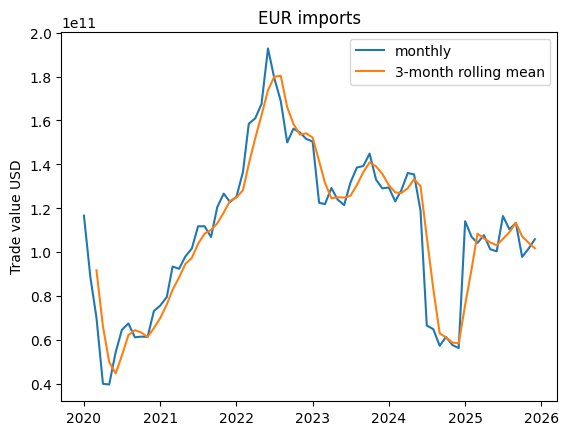

In [55]:
tmp = reporter_month[
    (reporter_month["reporter_iso3"] == "EUR") &
    (reporter_month["trade_flow"] == "import")
].sort_values("ref_date").copy()

tmp["rolling_3m"] = tmp["trade_value_usd"].rolling(3).mean()

plt.plot(tmp["ref_date"], tmp["trade_value_usd"], label="monthly")
plt.plot(tmp["ref_date"], tmp["rolling_3m"], label="3-month rolling mean")
plt.title("EUR imports")
plt.ylabel("Trade value USD")
plt.legend()
plt.show()


Reconcile helper tables back to the main silver fact

In [56]:
fact_df = con.sql(f"""
    SELECT *
    FROM read_parquet('{SILVER_ROOT.as_posix()}/**/*.parquet')
""").df()

InvalidInputException: Invalid Input Error: Failed to read file "/Users/chromazone/Documents/Python/Data Enginering Zoomcamp/Capstone_monthly/data/silver/comtrade/comtrade_fact/ref_year=2020/reporter_iso3=ESP/part_20260317T233325Z_46a53589.parquet": schema mismatch in glob: column "row_count" was read from the original file "/Users/chromazone/Documents/Python/Data Enginering Zoomcamp/Capstone_monthly/data/silver/comtrade/comtrade_fact/cmd_month.parquet", but could not be found in file "/Users/chromazone/Documents/Python/Data Enginering Zoomcamp/Capstone_monthly/data/silver/comtrade/comtrade_fact/ref_year=2020/reporter_iso3=ESP/part_20260317T233325Z_46a53589.parquet".
Candidate names: load_batch_id, source_file, source_year_partition, bronze_extracted_at, ref_date, year_month, quarter, ref_year, refMonth, period, reporterCode, reporter_iso3, reporter_name_clean, partnerCode, partner_iso3, partner_name_clean, is_world_partner, is_special_partner_bucket, is_country_like_partner, is_bilate

In [57]:
fact_rollup = (
    fact_df.groupby(["period", "reporter_iso3", "trade_flow"], as_index=False)
    ["trade_value_usd"].sum()
)

check = reporter_month.merge(
    fact_rollup,
    on=["period", "reporter_iso3", "trade_flow"],
    suffixes=("_helper", "_fact"),
    how="outer"
)

check["diff"] = check["trade_value_usd_helper"] - check["trade_value_usd_fact"]
check["diff"].abs().sort_values(ascending=False).head(20)


NameError: name 'fact_df' is not defined

Check 1: HS revision by year

In [30]:
silver_df.groupby(["ref_year", "classification_version"]).size()


ref_year  classification_version
2020      H5                        159186
2021      H5                        172179
2022      H6                        194212
2023      H6                        217518
2024      H6                        216697
2025      H6                        126104
dtype: int64

Check 2: World partner bucket

In [31]:
silver_df.groupby("partner_iso3")["trade_value_usd"].sum().sort_values(ascending=False).head(20)


partner_iso3
W00    1.600828e+13
USA    1.330621e+12
RUS    1.083639e+12
SAU    8.951022e+11
CAN    8.935977e+11
BRA    7.861142e+11
NGA    6.532765e+11
GBR    5.768088e+11
MEX    5.591336e+11
NOR    5.430837e+11
IRQ    5.254717e+11
KAZ    5.127765e+11
LBY    4.637810e+11
NLD    3.829178e+11
X1     3.792494e+11
DZA    3.381999e+11
BEL    3.346828e+11
ARE    2.618151e+11
AGO    2.553386e+11
FRA    2.295934e+11
Name: trade_value_usd, dtype: float64

Check 3: weight usability by commodity

In [32]:
silver_df.groupby("cmdCode")[["has_net_wgt", "has_gross_wgt", "is_qty_usable"]].mean()


,has_net_wgt,has_gross_wgt,is_qty_usable
cmdCode,,,
1001,0.981258,0.0,0.981827
1005,0.996395,0.0,0.997153
1006,0.997266,0.0,0.997573
1201,0.993411,0.0,0.994012
2709,0.971689,0.0,0.971689
2710,0.996072,0.0,0.996106


Check 4: CIF and FOB null behaviour

In [37]:
silver_df.groupby("trade_flow")[["cifvalue", "fobvalue", "trade_value_usd"]].apply(lambda x: x.isna().mean())


,cifvalue,fobvalue,trade_value_usd
trade_flow,,,
export,0.820314,0.000000,0.0
import,0.000000,0.709949,0.0


Check 5: duplicate business grain

In [39]:
silver_df.duplicated(subset=["period", "reporter_iso3", "partner_iso3", "flowCode", "cmdCode", "classification_version", "motCode", "partner2Code", "customsCode"]).sum()


np.int64(0)

In [ ]:
#null audit

In [ ]:
#duplicate audit

In [ ]:
#business rule checks

In [ ]:
#cleaning and standardisation

In [ ]:
#derived columns

In [ ]:
#partition columns

In [ ]:
#write parquet

In [ ]:
#verification read-back